In [1]:
%matplotlib inline
from IPython.display import display

from validphys.pdfgrids import xgrid

from ntkpdf.api import API
from ntkpdf.plotting.pdfplots_providers import DEFAULT_FLAVOURS, DEFAULT_YLABELS
from ntkpdf.plotting.pdfplots_utils import plot_grids
from ntkpdf.utils import XGRID, EVOL_LIST

Applying NTKPDF plotting style...
Using Keras backend


In [ ]:
common_dict = dict(
  dataset_inputs={"from_": "fit"},
  use_cuts="fromfit",
  theory={"from_": "fit"},
  theoryid={"from_": "theory"},
)
fit = "260526-ac-02-ntk-sgd"

In [7]:
EvolutionOperator = API.compute_ntk_decomposition_ensemble(fit=fit, **common_dict, training=True, name="model", epoch=50000, evol_fl_names=EVOL_LIST)
f0 = API.pdf_at_init(fit=fit, **common_dict)
learning_rate = API.learning_rate(fit=fit)
data_tr, _ = API.get_train_val_data(fit=fit, **common_dict)

/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'NN_input': 'NN_input'}
Received: inputs=Tensor(shape=(1, 50, 2))
  warnings.warn(msg)


In [12]:
ft = EvolutionOperator(100 * learning_rate, data_tr, f0)
ft_grid = EvolutionOperator.plotting_grid(100 * learning_rate, data_tr, f0)

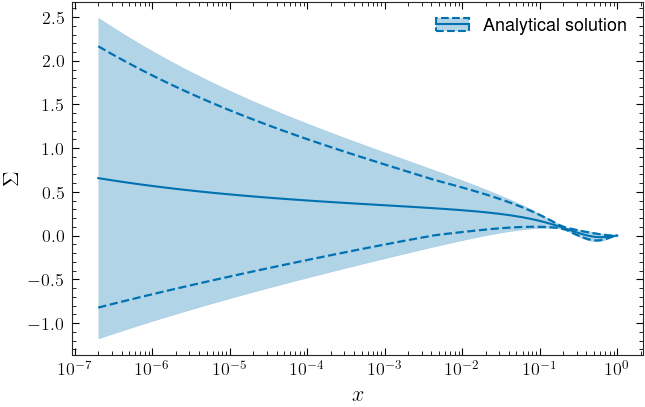

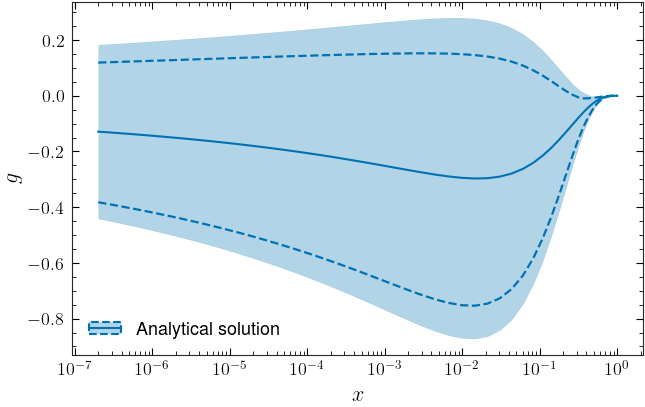

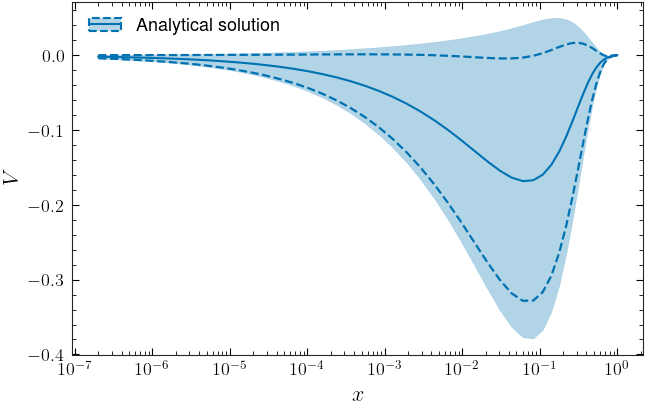

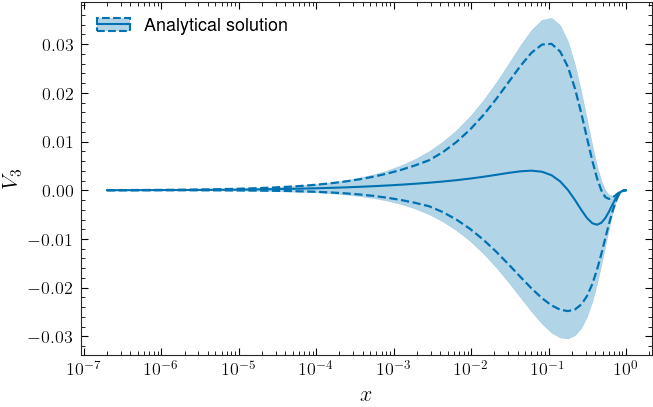

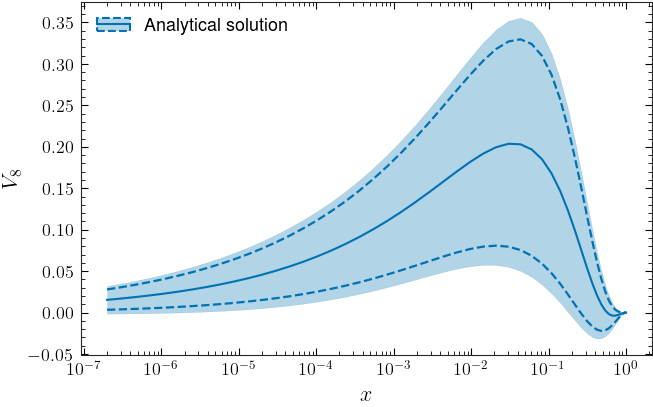

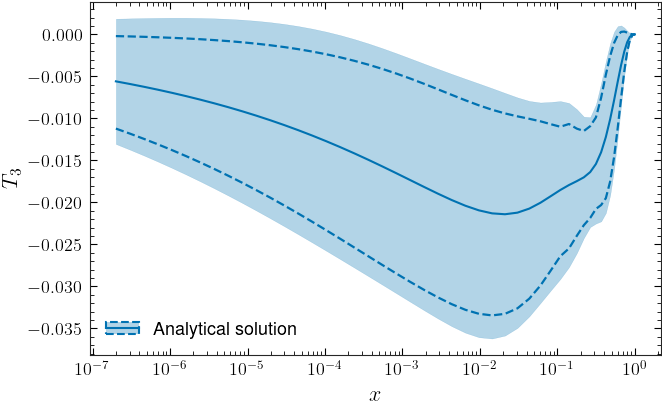

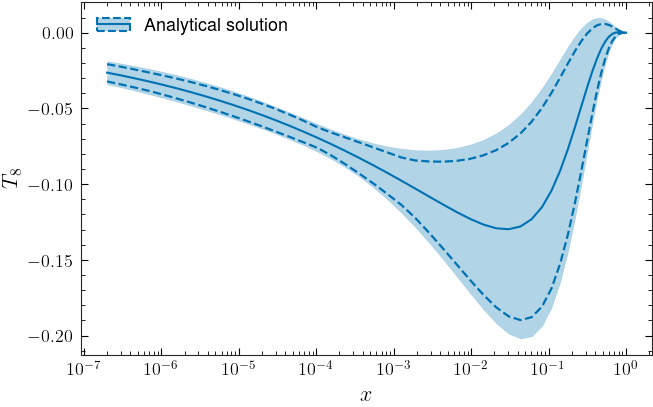

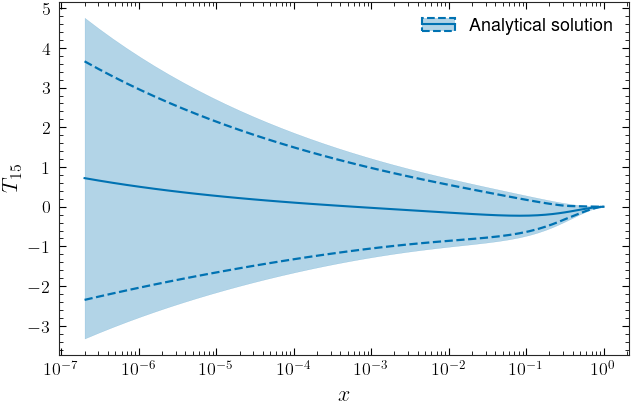

In [13]:
gen = plot_grids(
  [ft_grid],
  flavours=DEFAULT_FLAVOURS,
  ylabels=DEFAULT_YLABELS,
  labels=["Analytical solution"],
  # normalise_to=1,
  xscale="log",
)
figs = list(gen)

for fig in figs:
    display(fig)